Name Haoxin Ni

Labpartner(s)

In [3]:
#import statements go here
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

**For today's lab you need to install the package cartopy**

In [4]:
# you can install packages here in a notebook with pip or conda, 
# or in the anaconda navigator in the environments tab (reccommended)
# pip install cartopy
# conda install cartopy

In [5]:
# I had an old version of cartopy so I had to upgrade:
# pip install --upgrade cartopy

In [6]:
import cartopy.crs as ccrs   #import map styles/types
import cartopy.feature as cfeature  # features such as the ocean, coastlines rivers, etc

# Class 6.2

Today we will finish fiunction sharing and do more plotting

# Warmups 6.2

**W.1** Write some code that generates 15 random integers from 1-100. If the integers are divisible by 2 assign them to list "x" if they are divisible by three, assign them to list "y", if they are neither assign them to list "z". 

In [8]:
import numpy as np

nums = np.random.randint(1, 101, size=15)

# Create empty lists to store the sorted numbers
x = []  # divisible by 2
y = []  # divisible by 3
z = []  # divisible by neither 2 nor 3

# Loop through each number and assign it to the correct list
for n in nums:
    if n % 2 == 0:        # divisible by 2
        x.append(int(n))
    elif n % 3 == 0:      # not divisible by 2, but divisible by 3
        y.append(int(n))
    else:                 # divisible by neither
        z.append(int(n))

# Print the results
print("All numbers:", nums)
print("x (divisible by 2):", x)
print("y (divisible by 3):", y)
print("z (neither):", z)

All numbers: [24 38 25 19 44 51  8 79 22 65 58 36 43 56 24]
x (divisible by 2): [24, 38, 44, 8, 22, 58, 36, 56, 24]
y (divisible by 3): [51]
z (neither): [25, 19, 79, 65, 43]


# Lecture 6.2

### Agenda:

- Show us your functions
- Questions
- xarray package and plotting netcdf files


### Show us your functions (from Lab 5.2) - continued

### Questions

### Cartopy

Let's take the data we used last time and make the plot publication ready

There are a number of differnt map projections available in Cartopy.  
https://cartopy.readthedocs.io/stable/reference/projections.html
Robinson is often used for global maps

/opt/anaconda3/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely

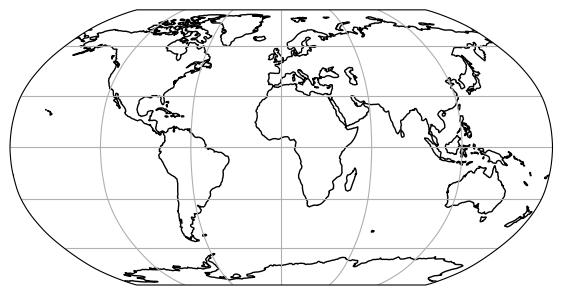

In [9]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson())
ax.coastlines(resolution='110m')
ax.gridlines()

When we are plotting ocean data, we like to make the Pacific contiguous, let's rotate

/opt/anaconda3/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


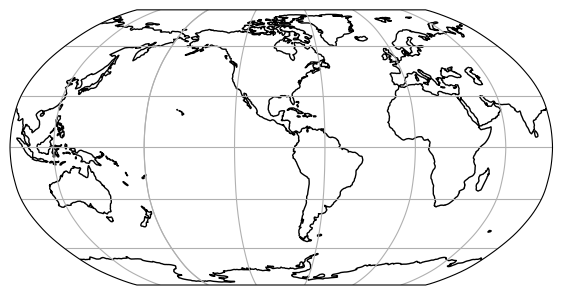

In [10]:
# plot a basic map with no data, rotated
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson(central_longitude = 360-89)) # this rotates the map to 203 degrees East
ax.coastlines(resolution='110m')
ax.gridlines()

Or we can rotate it so that it cuts through Indonesia (not good for mangrove or coral work)

/opt/anaconda3/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/set_operations.py:168: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/lib/python3.14/site-packages/

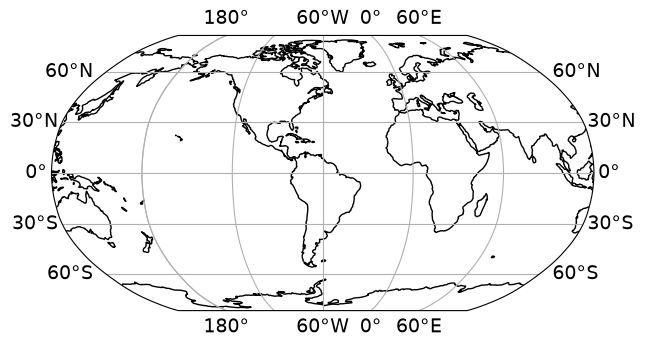

In [11]:
# plot a basic map with no data, rotated
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Robinson(central_longitude = -60))
# -60 (60 W) is the same as 300 E (360 degrees in total 360-60W = 300E)
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True) # let's add some labels



Let's try some different map projections

/opt/anaconda3/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


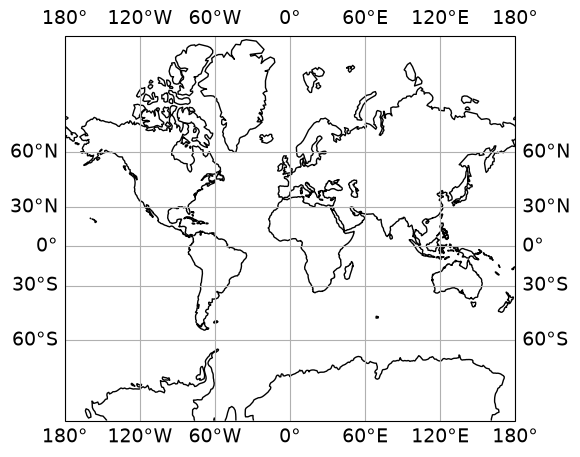

In [12]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.Mercator()) # different map projection
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)

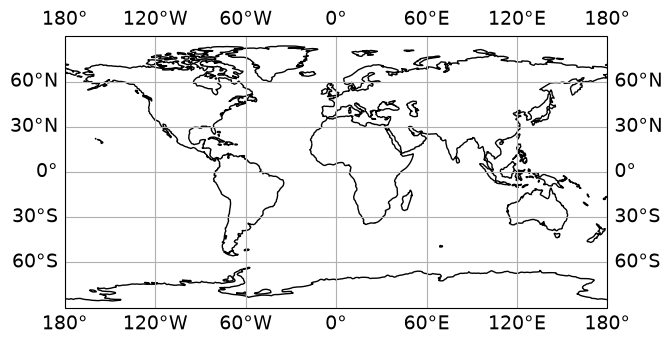

In [13]:
# plot a basic map with no data
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines(resolution='110m')
ax.gridlines(draw_labels=True)


How do I zoom in?

/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


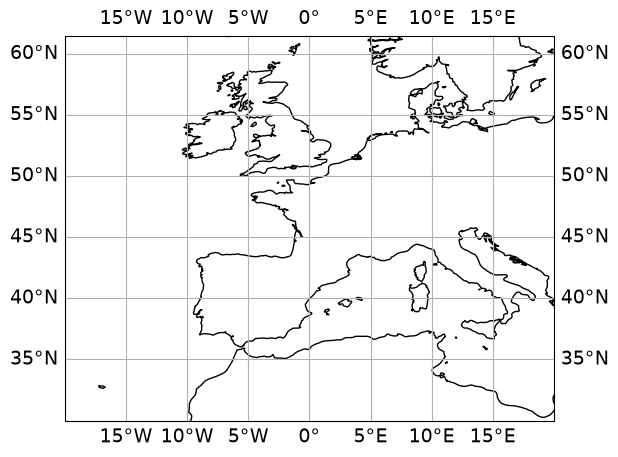

In [14]:
# let's zoom in to S Asia
plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-20,20,30,60]) # set the limits of the plot
ax.coastlines(resolution='50m') # more resolution
ax.gridlines(draw_labels=True)


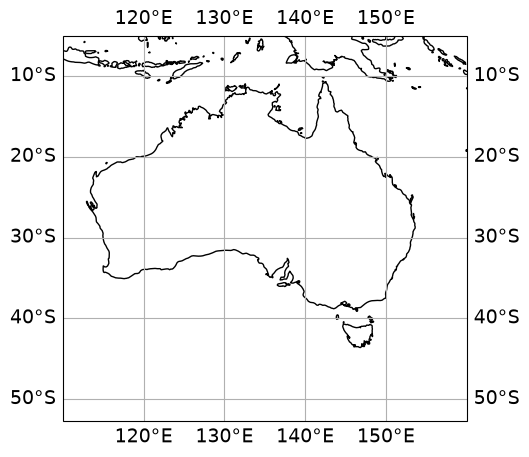

In [15]:
# make a plot of Australia

plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([110,160,-5,-50]) # set the limits of the plot
ax.coastlines(resolution='50m')
ax.gridlines(draw_labels=True)



#### Moving back to the Gulf of Mexico, we want to set the lat and lon range to match our HYCOM data. How do we find this?

In [16]:
#insert path or url to file here
# download from the internet:
link = "https://tds.hycom.org/thredds/dodsC/datasets/GOMe0.04/expt_03.9/data/archive/2026/039_archv.2026_001_00_2d.nc"

In [17]:
gom_data = xr.open_dataset(link, decode_times=False)

In [18]:
gom_data

<xarray.Dataset> Size: 5MB
Dimensions:                (MT: 1, Latitude: 385, Longitude: 525)
Coordinates:
  * MT                     (MT) float64 8B 4.566e+04
    Date                   (MT) float64 8B ...
  * Latitude               (Latitude) float32 2kB 18.09 18.13 ... 31.93 31.96
  * Longitude              (Longitude) float32 2kB -98.0 -97.96 ... -77.04
Data variables:
    surface_e_stress       (MT, Latitude, Longitude) float32 808kB ...
    surface_n_stress       (MT, Latitude, Longitude) float32 808kB ...
    ssh                    (MT, Latitude, Longitude) float32 808kB ...
    u_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    v_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    mixed_layer_thickness  (MT, Latitude, Longitude) float32 808kB ...
Attributes:
    Conventions:                     CF-1.6
    title:                           HYCOM
    source:                          HYCOM archive file
    experiment:                      01.4
    history:                         archv2ncdf2d
    comment:                         p-grid
    DODS_EXTRA.Unlimited_Dimension:  MT

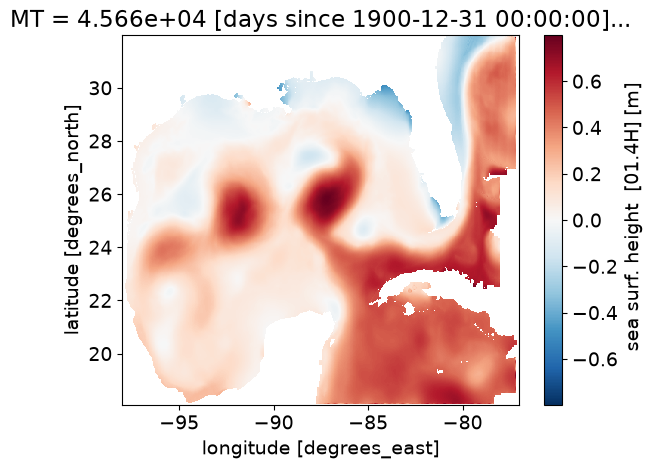

In [19]:
# let's remember what our data looked like, pick a variable to plot

gom_data.ssh.plot()

I'm going to get the max and min of the lat and lon to help me plot the data

In [20]:
lat_min = gom_data.Latitude.min()
print(lat_min)

<xarray.DataArray 'Latitude' ()> Size: 4B
array(18.091648, dtype=float32)
Attributes:
    standard_name:  latitude
    units:          degrees_north
    axis:           Y


In [21]:
lat_max = gom_data.Latitude.max()
print(lat_max)

<xarray.DataArray 'Latitude' ()> Size: 4B
array(31.960648, dtype=float32)
Attributes:
    standard_name:  latitude
    units:          degrees_north
    axis:           Y


In [22]:
lon_min = gom_data.Longitude.min()
print(lon_min)

<xarray.DataArray 'Longitude' ()> Size: 4B
array(-98., dtype=float32)
Attributes:
    standard_name:  longitude
    units:          degrees_east
    point_spacing:  even
    axis:           X


In [23]:
lon_max = gom_data.Longitude.max()
print(lon_max)

<xarray.DataArray 'Longitude' ()> Size: 4B
array(-77.03998, dtype=float32)
Attributes:
    standard_name:  longitude
    units:          degrees_east
    point_spacing:  even
    axis:           X


Now I can use them below

/opt/anaconda3/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


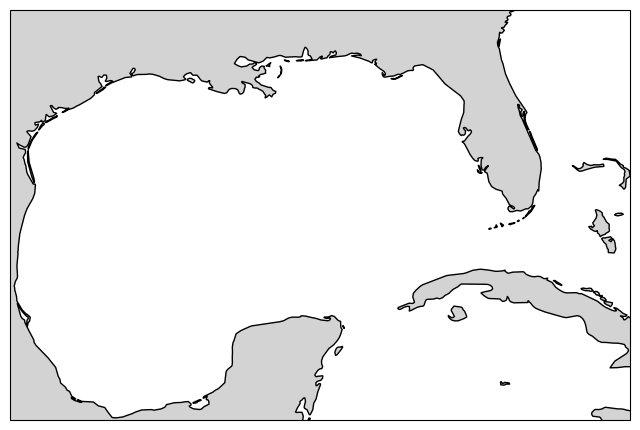

In [24]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 
# note the seqence of arguments for set_extent: x1, x2, y1, y2

#Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='lightgrey')
# you can use named colors: https://matplotlib.org/stable/gallery/color/named_colors.html
# or with other methods: https://matplotlib.org/stable/users/explain/colors/colors.html

ax.add_feature(land_50m)

#### Let's make the land color a bit lighter gray

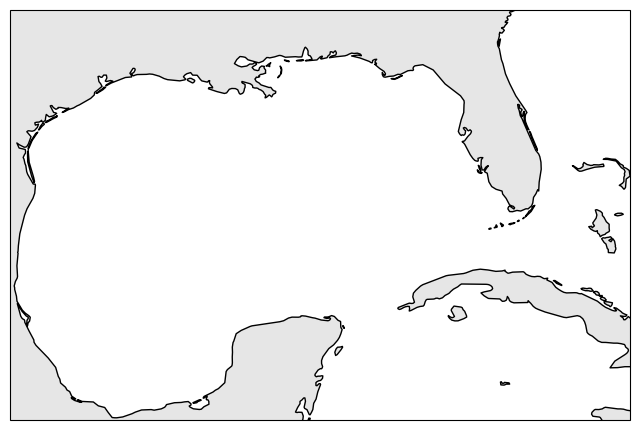

In [25]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 
# note the seqence of arguments for set_extent: x1, x2, y1, y2

#Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9') # 0 is black and 1 is white
# you can use named colors: https://matplotlib.org/stable/gallery/color/named_colors.html
# or with other methods: https://matplotlib.org/stable/users/explain/colors/colors.html

ax.add_feature(land_50m)

#### Now let's add some data

In [26]:
var = gom_data.ssh[0,:,:] # get rid of the time dimension
var

<xarray.DataArray 'ssh' (Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
    MT         float64 8B 4.566e+04
    Date       float64 8B ...
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]
    _ChunkSizes:    [  1 385 525]

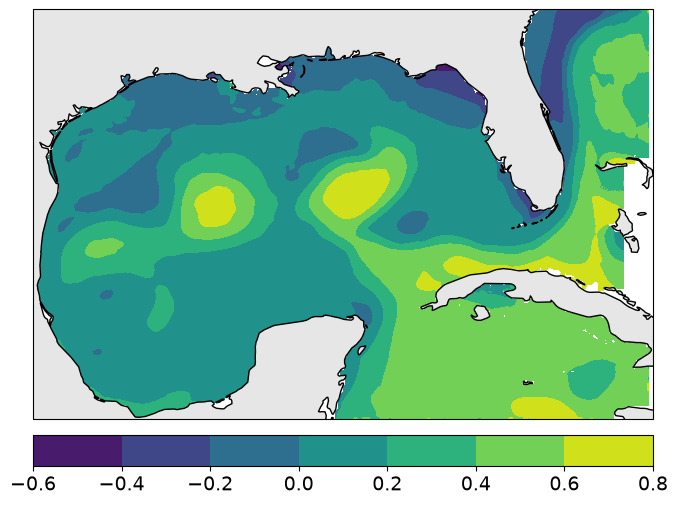

In [27]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent( [lon_min, lon_max, lat_min, lat_max]) 

# Sets the land onto the projection with the right color and scale
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.9')
ax.add_feature(land_50m)

# let's fill in the following:
x = gom_data['Longitude']
y = gom_data['Latitude']

# Contours the data on tho the map projection
p = ax.contourf(x, y, var, transform=ccrs.PlateCarree()) # projection is needed in every plot call

# Creates colorbar based on the contour. This allows us to get a quick look at our data range 
# before we start formatting the figure 
cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)


#### Try taking out the options for the colorbar, what happens? What does "pad" do?

In [28]:
?plt.colorbar

Signature:
plt.colorbar(
    mappable: 'ScalarMappable | ColorizingArtist | None' = None,
    cax: 'matplotlib.axes.Axes | None' = None,
    ax: 'matplotlib.axes.Axes | Iterable[matplotlib.axes.Axes] | None' = None,
    **kwargs,
) -> 'Colorbar'
Docstring:
Add a colorbar to a plot.

Parameters
----------
mappable
    The `matplotlib.colorizer.ColorizingArtist` (i.e., `.AxesImage`,
    `.ContourSet`, etc.) described by this colorbar.  This argument is
    mandatory for the `.Figure.colorbar` method but optional for the
    `.pyplot.colorbar` function, which sets the default to the current
    image.

    Note that one can create a `.colorizer.ColorizingArtist` "on-the-fly"
    to generate colorbars not attached to a previously drawn artist, e.g.
    ::

        cr = colorizer.Colorizer(norm=norm, cmap=cmap)
        fig.colorbar(colorizer.ColorizingArtist(cr), ax=ax)

cax : `~matplotlib.axes.Axes`, optional
    Axes into which the colorbar will be drawn.  If `None`, then a new
    Axes i

#### What is the range of our data?

In [29]:
print(var.max())

<xarray.DataArray 'ssh' ()> Size: 4B
array(0.7986358, dtype=float32)
Coordinates:
    MT       float64 8B 4.566e+04
    Date     float64 8B ...
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]
    _ChunkSizes:    [  1 385 525]


In [30]:
print(var.min())

<xarray.DataArray 'ssh' ()> Size: 4B
array(-0.504511, dtype=float32)
Coordinates:
    MT       float64 8B 4.566e+04
    Date     float64 8B ...
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]
    _ChunkSizes:    [  1 385 525]


#### Let's set the countour levels to match our data range. I'm also going to change the colormap
See https://matplotlib.org/stable/users/explain/colors/colormaps.html
Note you can reverse any colormap by appending '_r' to the name

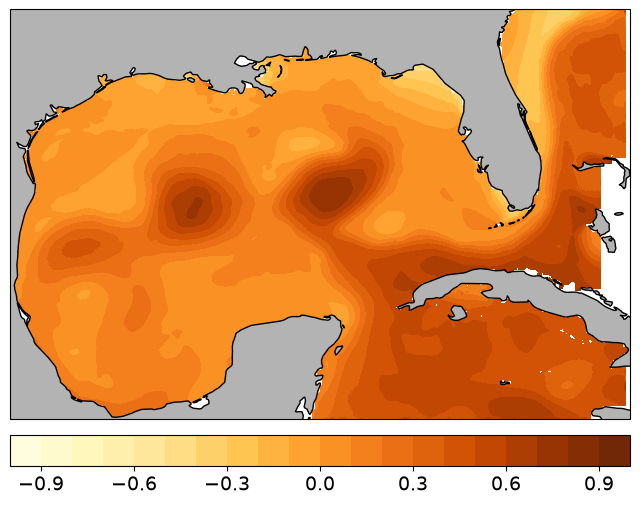

In [31]:
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# let's fill in the range here:
step = np.arange(-1, 1.1, 0.1)  # start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'YlOrBr', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)


#### Okay, now let's add some labels

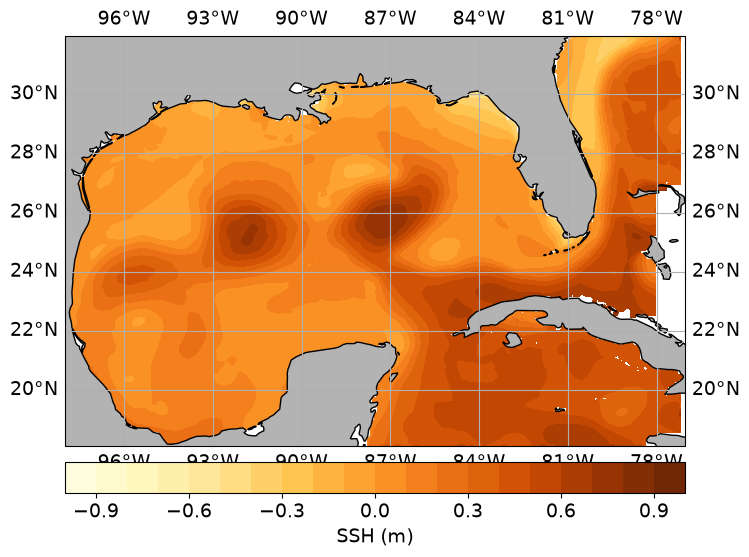

In [32]:
# copy in previous code here
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# let's fill in the range here:
step = np.arange(-1, 1.1, 0.1)  # start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'YlOrBr', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)
# I'm also going to cut out the white bits at right by adjusting lon_max


cbar.set_label("SSH" +' (m)', size = 14)

ax.gridlines(draw_labels=True)


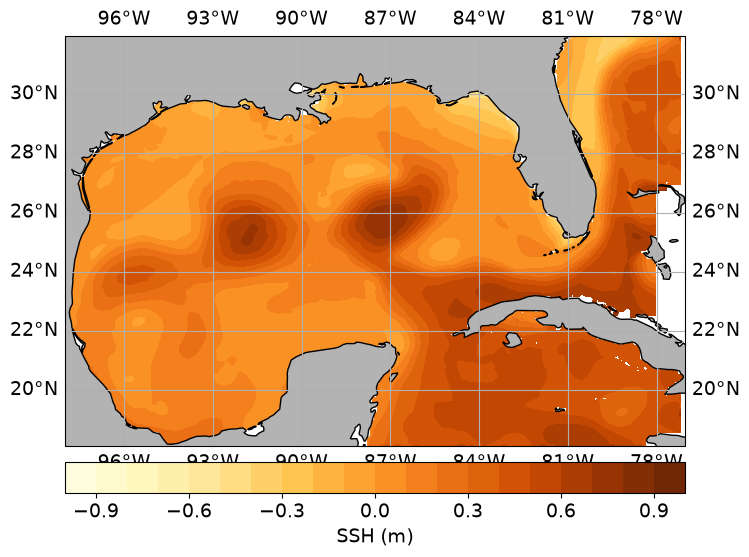

In [33]:
# copy in previous code here
fig,ax= plt.subplots(figsize =(8,10),subplot_kw=dict(projection=ccrs.PlateCarree()))
ax.set_extent([lon_min, lon_max, lat_min, lat_max]) 

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                    edgecolor='black',
                                    facecolor='0.7')
ax.add_feature(land_50m)

x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.ssh[0,:,:]

# let's fill in the range here:
step = np.arange(-1, 1.1, 0.1)  # start, stop, step
p = ax.contourf(x, y,var, transform=ccrs.PlateCarree(), cmap = 'YlOrBr', 
                    levels = step) # projection is needed in every plot call

cbar = plt.colorbar(p, orientation='horizontal', pad=0.02)
# I'm also going to cut out the white bits at right by adjusting lon_max


cbar.set_label("SSH" +' (m)', size = 14)

ax.gridlines(draw_labels=True)

import matplotlib as mpl
mpl.rcParams['font.size'] = 14

#### These labels are too small for what I want. I need them to be much bigger.

In [34]:
#Note we can easily make the lat/lon and colorbar font size bigger by adjusting the matplotlib parameters, 
# which I introduced last time
import matplotlib as mpl
mpl.rcParams['font.size'] = 14

In [35]:
#exact same code as before


#### Not bad

## Lab 6.2

**E.0** Finish Lab 6.1 if you haven't already.

**E.1** Complete Introduction to Data Visualization with Matplotlib Chapters 3-4. Let me know if this feels like a good pace

**E.2** Make notes for yourself on progamming tecniques and commands you learned in the lecture and datacamp chapter above, including examples, comments and explainitory text. You can do this here or in a separate notebook that you link to here. Basically, you are making a cheat sheet for yourself.

1. Choosing a plot type: Bar charts compare categories, histograms show distributions, scatter plots show relationships, and boxplots summarize the spread of data.

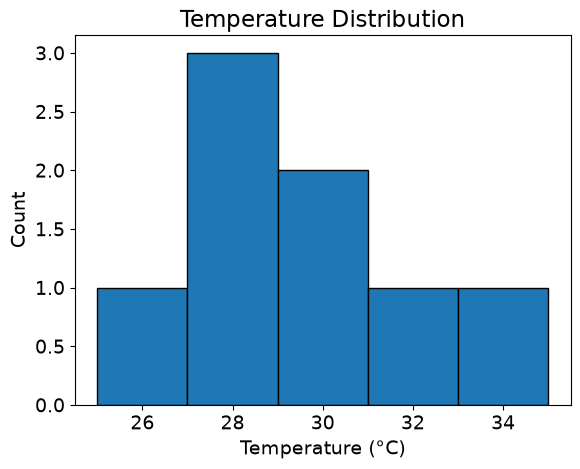

In [55]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

# A histogram shows how values are distributed
temperatures = [25, 27, 28, 28, 29, 30, 32, 35]
ax.hist(temperatures, bins=5, edgecolor='black')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Count')
ax.set_title('Temperature Distribution')
plt.show()

2. Error bars: Error bars can show variability or uncertainty. I should explain what they represent.

<BarContainer object of 2 artists>

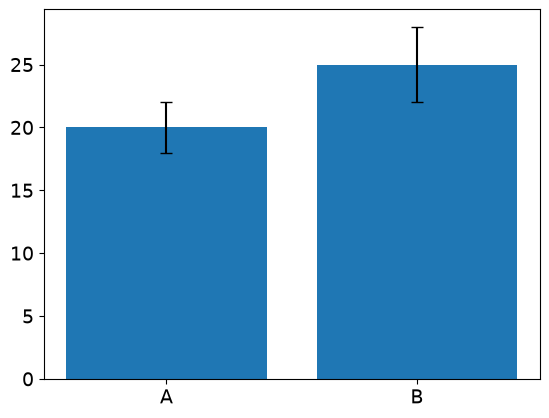

In [57]:
# Compare two means and show their standard deviations
fig, ax = plt.subplots()
ax.bar(['A', 'B'], [20, 25], yerr=[2, 3], capsize=4)

3. Customizing and saving figures: Labels, figure size, and style make plots easier to read. I should save the figure before calling plt.show().

In [59]:
plt.style.use('default')
fig.set_size_inches(8, 5)

# Save a high-resolution image with less empty space
fig.savefig('my_plot.png', dpi=300, bbox_inches='tight')
plt.show()

4. Reading NetCDF data with xarray: xr.open_dataset() opens a dataset. Printing the dataset helps me check variable names, dimensions, and units.

In [60]:
import xarray as xr

# Replace this example filename with the actual data file
ds = xr.open_dataset('data.nc')
print(ds)

# Find the highest daily temperature at each grid point
maximum_temperature = ds.tasmax.max(dim='time') - 273.15
# Subtract 273.15 to convert Kelvin to Celsius

FileNotFoundError: [Errno 2] No such file or directory: '/Users/finley/Jupyter/week6/data.nc'

5. Making maps with Cartopy: projection sets the map projection, while transform describes the coordinates of the plotted data.

/opt/anaconda3/lib/python3.14/site-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


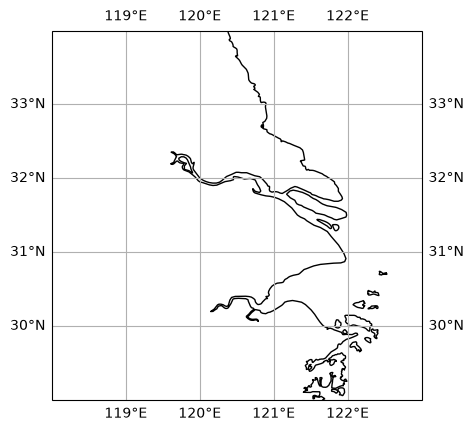

In [61]:
import cartopy.crs as ccrs

fig, ax = plt.subplots(
    subplot_kw=dict(projection=ccrs.PlateCarree())
)

# Extent order: west, east, south, north
ax.set_extent([118, 123, 29, 34], crs=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels=True)
plt.show()

6. Colormaps and contour levels: contourf() draws filled contours. levels controls the intervals, and cmap controls the colors. For temperature differences, I can use RdBu_r with levels symmetric around zero.

7. Reusing code: A plotting function saves time when making similar figures. Using the same color scale also makes historical and future maps easier to compare.

**E.3** Make a plot of a different variable for the HYCOM data. Play around with colormaps and contourlines to make it your own. Post your plot on the class slack #programming channel

/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


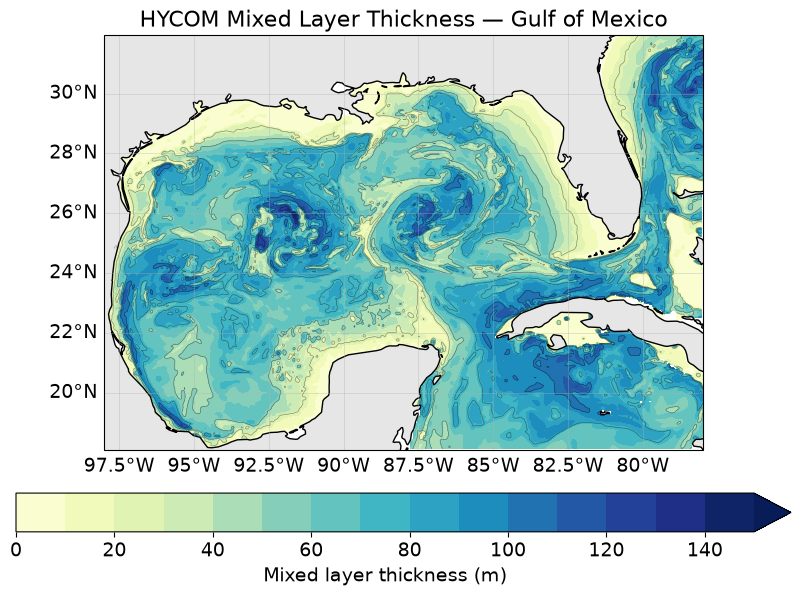

In [43]:
# Plot mixed layer thickness
x = gom_data.Longitude
y = gom_data.Latitude
var = gom_data.mixed_layer_thickness[0, :, :]

fig, ax = plt.subplots(
    figsize=(10, 7),
    subplot_kw=dict(projection=ccrs.PlateCarree())
)
ax.set_extent(
    [lon_min, -78, lat_min, lat_max],
    crs=ccrs.PlateCarree()
)

land_50m = cfeature.NaturalEarthFeature(
    'physical', 'land', '50m',
    edgecolor='black', facecolor='0.9'
)
ax.add_feature(land_50m)

# Filled contours
step = np.arange(0, 151, 10)
p = ax.contourf(
    x, y, var,
    transform=ccrs.PlateCarree(),
    cmap='YlGnBu', levels=step, extend='max'
)

# Subtle contour lines without number labels
ax.contour(
    x, y, var,
    transform=ccrs.PlateCarree(),
    levels=[25, 50, 75, 100, 125],
    colors='black', linewidths=0.5, alpha=0.4
)

cbar = plt.colorbar(p, ax=ax, orientation='horizontal', pad=0.08)
cbar.set_label('Mixed layer thickness (m)', size=14)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.set_title('HYCOM Mixed Layer Thickness — Gulf of Mexico', fontsize=16)

plt.savefig('E3_mixed_layer_thickness.png', dpi=300, bbox_inches='tight')
plt.show()

### This week's project:

#### Note you might want to restart your kernel at this point to dump all the hycom data from memory. Just reload the packages you need

**E.4** Download some data from the ISIMIP data archive (https://data.isimip.org/) and plot it using cartopy. ISIMIP provides bias-corrected daata for past and future climate simulations used for impacts studies world wide. Let's start with some maximum atmospheric surface temperature data in the historical period (1850-2014 for CMIP6). We want climate forcing data for ISIMIP3b, which are the lastest (CMIP6) climate projections. 

* https://data.isimip.org/search/tree/ISIMIP3b/InputData/climate/
* Click atmopsheric forcing
* Click GFDL... This is one of NOAA-GFDL's climate models (ESM4)
* Click historical

All of the variable names are in CMIP lingo. Sadly, there is no easy cheat sheet. But you want tas, which is "temperature of air at surface". Let's use the tasmax, the maximum daily surface air temperature
* Click tasmax
* Click files to see all the available files.
  
Here you have a choice, you can download an etire file (note the size) or you can use the "configure download" button, which has subsetting by space or country, as well as time opitons. You can click on a file name to see more info.
* Click on "download file" for the 1851-1860 file. Just grab the whole file, it will take a minute to download.
* Load up the data into xarray and plot the maximum of this dataset (so max over the decade for each gridcell. You just use a max function for this, no loops needed).
* Plot using cartopy to make it pretty. Put some sensible lables on it, etc. Maybe add some country boundaries.

In [51]:
from pathlib import Path # Deal with the path issues, i put the files in my portable disk
from cartopy.util import add_cyclic_point # Connect the data at both ends of the global map

folder = Path('/Volumes/O5-Files') # file path

def plot_map(data, title, levels, cmap, filename,
             label='Temperature (°C)', extent=None):

    """
    Plot the figures.
    """

    fig, ax = plt.subplots(
        figsize=(10, 6),
        subplot_kw=dict(projection=ccrs.PlateCarree())
    )

    if extent is None:
        ax.set_global()
        # Connect the data across the international date line
        values, lon = add_cyclic_point(
            data.values, coord=data.lon.values
        )
    else:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        values, lon = data.values, data.lon.values

    p = ax.contourf(
        lon, data.lat, values,
        transform=ccrs.PlateCarree(),
        levels=levels, cmap=cmap, extend='neither'
    )

    resolution = '110m' if extent is None else '50m'
    ax.coastlines(resolution=resolution, linewidth=0.6)
    ax.add_feature(
        cfeature.BORDERS.with_scale('110m'), linewidth=0.4
    )

    gl = ax.gridlines(
        draw_labels=True, linewidth=0.4, alpha=0.4
    )
    gl.top_labels = False
    gl.right_labels = False

    cbar = fig.colorbar(
        p, ax=ax, orientation='horizontal',
        pad=0.08, shrink=0.85
    )
    cbar.set_label(label, fontsize=12)
    ax.set_title(title, fontsize=14)

    fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

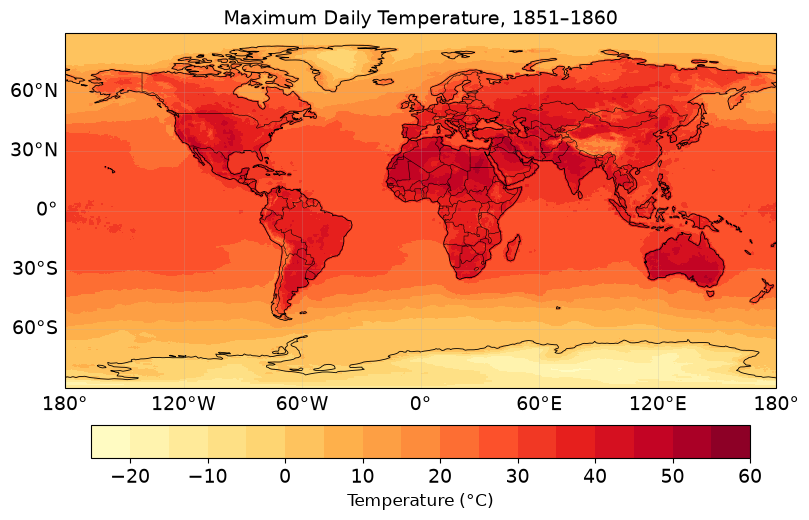

In [52]:
historical_file = folder / (
    'gfdl-esm4_r1i1p1f1_w5e5_historical_'
    'tasmax_global_daily_1851_1860.nc'
)

with xr.open_dataset(historical_file, chunks={'time': 100}) as ds:
    hist_max = (
        ds.tasmax.max(dim='time') - 273.15
    ).compute(scheduler='synchronous')

# Use the same temperature scale for E4 and E5
temperature_levels = np.arange(-25, 61, 5)

plot_map(
    hist_max,
    'Maximum Daily Temperature, 1851–1860',
    temperature_levels,
    'YlOrRd',
    'E4_historical_temperature.png'
)

**E.5** Now make a second plot using ISIMP data for a future climate projection. Following the same steps as above, get the GFDL tasmax data for the future climate scenario SSP3-7.0 (higher emissions scenario) for 2051-2060. Again, calculate the maximum at each gridpoint for this data set. This is the future maximum daily temperature for that decade. Make your plot nice.

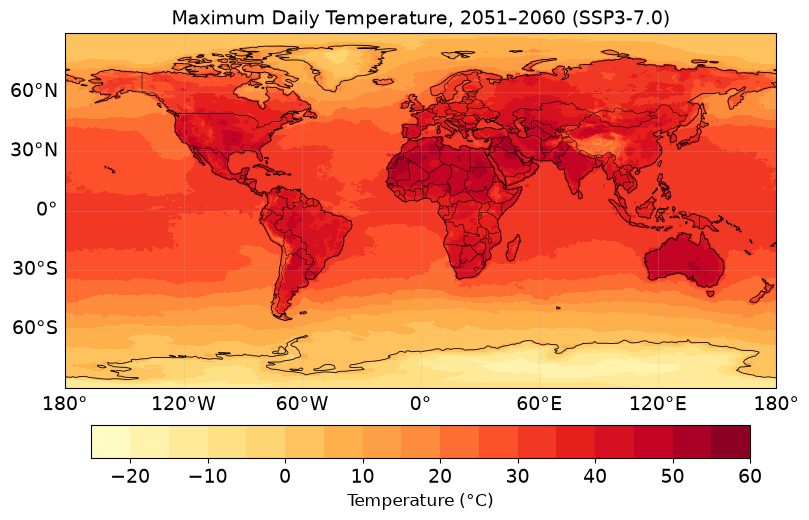

In [53]:
future_file = folder / (
    'gfdl-esm4_r1i1p1f1_w5e5_ssp370_'
    'tasmax_global_daily_2051_2060.nc'
)

with xr.open_dataset(future_file, chunks={'time': 100}) as ds:
    future_max = (
        ds.tasmax.max(dim='time') - 273.15
    ).compute(scheduler='synchronous')

plot_map(
    future_max,
    'Maximum Daily Temperature, 2051–2060 (SSP3-7.0)',
    temperature_levels,
    'YlOrRd',
    'E5_future_temperature.png'
)

**E.6** Now plot the anomaly between the two, 2050's - 1850's. Use a diverging colormap (light in the middle), centered on zero. What is the outlook for your country of orgin? Answer in full sentances with specific numbers.

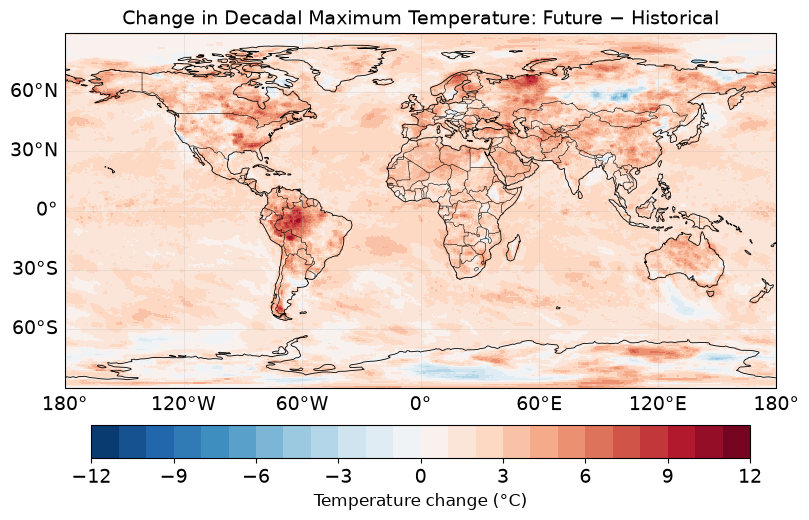

/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


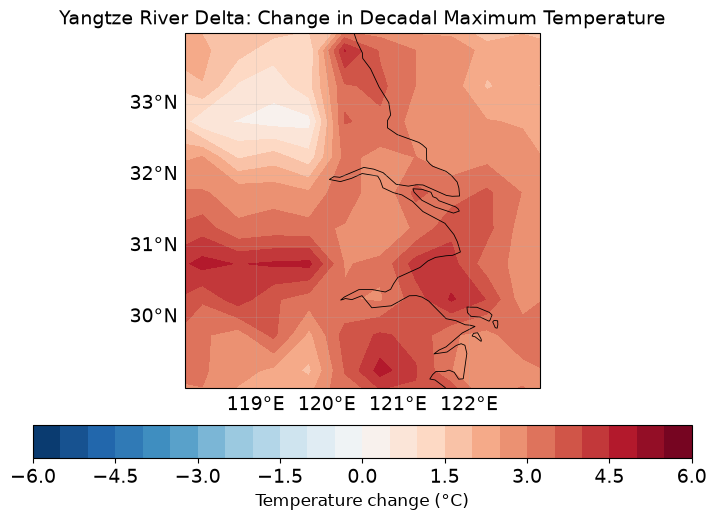

Shanghai: historical = 38.31 °C, future = 41.38 °C, change = 3.07 °C
Hangzhou: historical = 39.14 °C, future = 42.19 °C, change = 3.05 °C
Nanjing: historical = 38.68 °C, future = 40.10 °C, change = 1.42 °C


In [54]:
anomaly = future_max - hist_max

plot_map(
    anomaly,
    'Change in Decadal Maximum Temperature: Future − Historical',
    np.arange(-12, 13, 1),
    'RdBu_r',
    'E6_global_anomaly.png',
    label='Temperature change (°C)'
)

# Include a small margin around the displayed area to avoid white edges.
# Latitude runs from north to south in these datasets.
delta_anomaly = anomaly.sel(
    lon=slice(117.5, 123.5),
    lat=slice(34.5, 28.5)
)

plot_map(
    delta_anomaly,
    'Yangtze River Delta: Change in Decadal Maximum Temperature',
    np.arange(-6, 6.5, 0.5),
    'RdBu_r',
    'E6_Yangtze_River_Delta.png',
    label='Temperature change (°C)',
    extent=[118, 123, 29, 34]
)

# Extract the nearest model grid point for each city
cities = {
    'Shanghai': (31.23, 121.47),
    'Hangzhou': (30.27, 120.15),
    'Nanjing': (32.06, 118.80)
}

for city, (lat, lon) in cities.items():
    historical = float(
        hist_max.sel(lat=lat, lon=lon, method='nearest')
    )
    future = float(
        future_max.sel(lat=lat, lon=lon, method='nearest')
    )

    print(
        f'{city}: historical = {historical:.2f} °C, '
        f'future = {future:.2f} °C, '
        f'change = {future - historical:.2f} °C'
    )

I focus on the Yangtze River Delta in coastal China. In the GFDL-ESM4 simulation under SSP3-7.0, the decadal maximum daily temperature at the model grid point nearest Shanghai increases from 38.31°C in 1851–1860 to 41.38°C in 2051–2060, a rise of 3.07°C. The corresponding increases are 3.05°C near Hangzhou and 1.42°C near Nanjing. These results suggest higher peak temperatures in this region under the selected scenario. The values represent maxima over each ten-year period, rather than changes in annual mean temperature, and come from one model simulation.

**E.7** How could you potentially use this kind of data (future climate projections) in your research? Do some brainstorming. Write down your thoughts here.

My interest in hurricanes and climate dynamics became very personal this year. Around the time I was flying to the United States, a powerful typhoon made landfall and nearly prevented my flight from taking off. Apparently, the atmosphere wanted one last opportunity to review my travel plans before letting me leave.
With this year’s El Niño strengthening and forecast to become very strong, I am especially interested in investigating how ENSO and long-term warming might affect typhoons approaching coastal China. I could use future climate projections to compare extreme temperatures in the Yangtze River Delta under different emissions scenarios. Combining these projections with sea surface temperature, humidity, atmospheric winds, and typhoon tracks would help me explore changes in storm environments and possible compound events, such as extreme heat occurring before or after a typhoon.
The tasmax data in this lab provide a starting point for studying temperature extremes, but investigating typhoon intensity and tracks would require additional variables. I would also compare multiple climate models to assess uncertainty. Ultimately, I hope to understand these storms better—and perhaps improve the odds that my next international journey begins with a boarding pass rather than an unexpected field study.